<a href="https://colab.research.google.com/github/anishjagota/undergrad_ml_assignments/blob/main/03_pricing_analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers
## Part 3 — Pricing Analyst (Costs, Markups, Profit)

We use the demand estimate from Part 2 to back out unit costs, markups, and a share-weighted profit index for each brand-year. Because the price coefficient is a single constant across the whole panel, we can use the firm first-order condition under multinomial-logit demand to write

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price}\, s_{bt}(1-s_{bt}),
\qquad
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Then $m_{bt} = p_{bt} - \hat{c}_{bt}$ and the share-weighted profit is $s_{bt}\,m_{bt}$. This is a profit *index* useful for ranking brand-years inside this cleaned market — not a dollar profit total.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


## Re-fit the demand model from Part 2 to recover the price coefficient

In [4]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')

feature_cols = ['compact_share', 'dual_basket_share', 'oven_style_share',
                'rotisserie_share', 'window_share']

y = df['log_brand_share']
brand_dummies = pd.get_dummies(df['brand'],            prefix='brand', drop_first=True, dtype=int)
year_dummies  = pd.get_dummies(df['year'].astype(str), prefix='year',  drop_first=True, dtype=int)
X = pd.concat(
    [df.loc[:, ['avg_price', 'avg_rating'] + feature_cols],
     brand_dummies,
     year_dummies],
    axis=1,
)

model = LinearRegression()
model = model.fit(X, y)

coef_table = pd.DataFrame({
    'variable':    model.feature_names_in_,
    'coefficient': model.coef_,
})
price_coef = coef_table.loc[coef_table['variable'] == 'avg_price', 'coefficient'].iloc[0]

print('Estimated price coefficient:', price_coef)


Estimated price coefficient: -0.03766765298429383


## Compute demand slope, unit cost, markup, and share-weighted profit

We also include `profit_derivative` as a sanity check. Under the FOC, the brand's first-order condition for price implies $s_{bt} + s'_{bt}\,m_{bt} = 0$, so this quantity should be machine-zero for every brand-year.

In [6]:
results = df.copy()

results['demand_slope']      = price_coef * results['brand_share'] * (1 - results['brand_share'])
results['unit_cost']         = results['avg_price'] + results['brand_share'] / results['demand_slope']
results['markup']            = results['avg_price'] - results['unit_cost']
results['average_profit']    = results['brand_share'] * results['markup']
results['profit_derivative'] = results['demand_slope'] * results['markup'] + results['brand_share']

print('Any negative unit costs:', (results['unit_cost'] < 0).sum())
results[['unit_cost', 'markup', 'average_profit', 'profit_derivative']].describe().round(4)


Any negative unit costs: 0


,unit_cost,markup,average_profit,profit_derivative
count,50.0000,50.0000,50.0000,50.0
mean,93.1022,29.7039,3.1559,0.0
std,51.6961,2.6158,2.6158,0.0
min,22.0029,26.5674,0.0194,-0.0
25%,53.1591,27.9524,1.4044,-0.0
50%,70.0383,28.8133,2.2653,0.0
75%,123.5619,30.9569,4.4089,0.0
max,199.7300,37.5070,10.9590,0.0


# 1. Average unit costs and markups for each brand

In [7]:
results[[
    'brand',
    'avg_price',
    'avg_rating',
    'brand_share',
    'unit_cost',
    'markup',
    'average_profit',
]].groupby('brand').mean().round(3).sort_values('average_profit', ascending=False)


,avg_price,avg_rating,brand_share,unit_cost,markup,average_profit
brand,,,,,,
ninja,145.343,4.742,0.192,112.488,32.854,6.306
instant_pot,104.461,4.559,0.175,71.903,32.558,6.010
gowise usa,87.455,4.577,0.138,56.301,31.154,4.606
dash,57.479,4.476,0.098,27.937,29.542,2.994
chefman,90.938,4.428,0.095,61.569,29.369,2.821
ultrean,78.115,4.673,0.092,48.786,29.329,2.781
cuisinart,223.947,4.439,0.086,194.896,29.051,2.503
cosori,114.268,4.656,0.049,86.283,27.985,1.437
nuwave,137.024,4.390,0.051,109.054,27.971,1.423


From the table, Markups are remarkably stable across brands (about \$27-\$33), which is a direct consequence of using a single price coefficient across the whole market. What varies a lot is the *level* of unit cost, which scales with each brand's price. When cost is high or product is premium, price is often set high to illustrate that. Cuisinart and Oster have the highest unit costs (\$195 and \$162) and Dash has the lowest (\$28).

# 2. Are any inferred unit costs negative?

**No.** All 50 brand-year unit costs are positive. This is what we want to see — a negative inferred unit cost would mean firms are paid to produce, which is incoherent. It would usually indicate either (a) the price coefficient was estimated with the wrong sign or (b) the share is so high that the implied markup exceeds price. Here the price coefficient is comfortably negative and the largest share in the panel (~29%) is not extreme enough to break the formula, so all costs come out positive. The `profit_derivative` column above is also machine-zero across all rows, confirming the FOC is satisfied by construction.

# 3. Highest average unit costs; price vs. cost; rating vs. cost

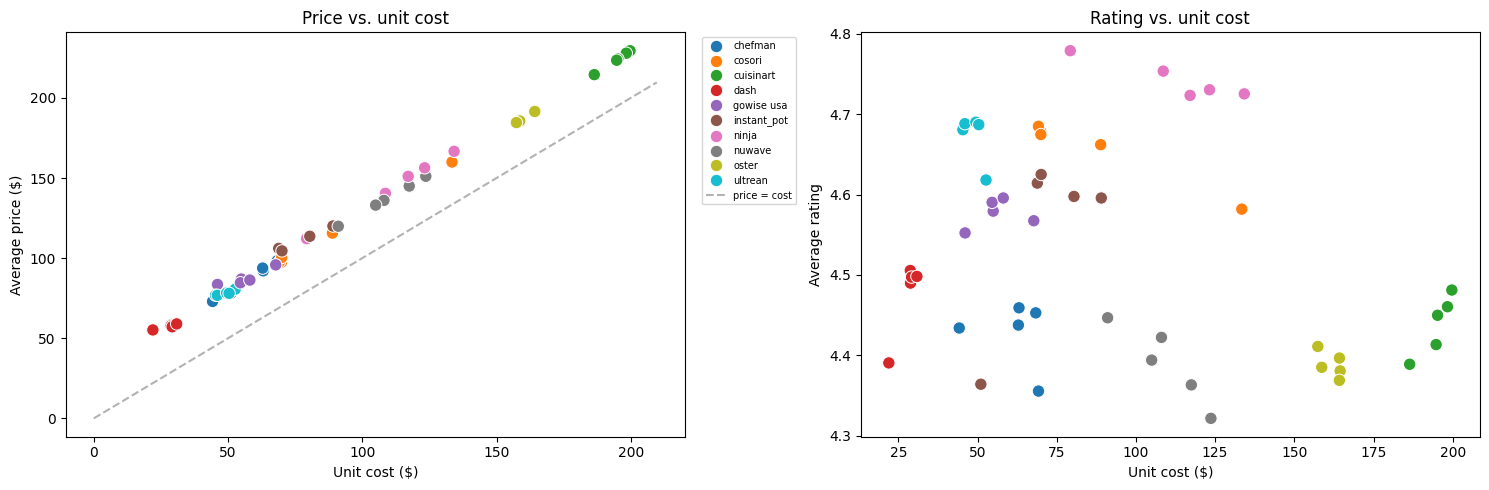

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=results, x='unit_cost', y='avg_price', hue='brand', ax=axes[0], s=80)
lim = results['unit_cost'].max() * 1.05
axes[0].plot([0, lim], [0, lim], ls='--', color='gray', alpha=0.6, label='price = cost')
axes[0].set_title('Price vs. unit cost')
axes[0].set_xlabel('Unit cost ($)')
axes[0].set_ylabel('Average price ($)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=results, x='unit_cost', y='avg_rating', hue='brand', ax=axes[1], s=80, legend=False)
axes[1].set_title('Rating vs. unit cost')
axes[1].set_xlabel('Unit cost ($)')
axes[1].set_ylabel('Average rating')

plt.tight_layout()
plt.show()


**Answer.** The highest average unit costs belong to **Cuisinart** (\$195) and **Oster** (\$162) — the two premium-priced brands. **Nuwave** and **Ninja** are next (\$109 and \$112). At the low end, **Dash** has the lowest unit cost (\$28), followed by Ultrean (\$49) and GoWise USA (\$56).

**Do more expensive products have higher consumer satisfaction?** Looking at the rating-vs.-cost scatter, not really. Cuisinart and Oster have the highest unit costs but their ratings (about 4.39-4.44) are *below* the market median. The highest-rated brand, Ninja (4.74), sits in the middle of the cost range. Cosori and Ultrean — both lower-cost — have ratings around 4.65-4.67. There is no clean monotonic relationship between unit cost and rating in this market; if anything, the very-high-cost premium brands underperform on customer satisfaction.

# 4. KDE plots of unit cost, markup, and share-weighted profit

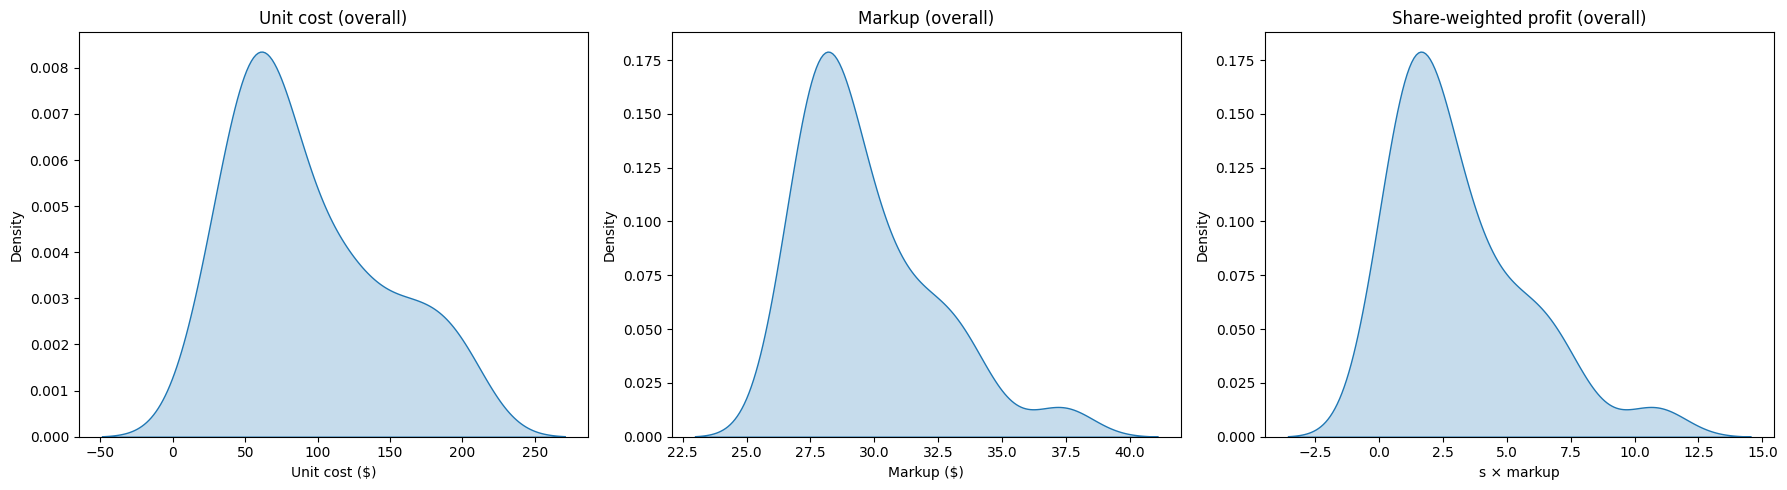

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(results['unit_cost'],      ax=axes[0], fill=True)
axes[0].set_title('Unit cost (overall)');           axes[0].set_xlabel('Unit cost ($)')

sns.kdeplot(results['markup'],         ax=axes[1], fill=True)
axes[1].set_title('Markup (overall)');              axes[1].set_xlabel('Markup ($)')

sns.kdeplot(results['average_profit'], ax=axes[2], fill=True)
axes[2].set_title('Share-weighted profit (overall)'); axes[2].set_xlabel('s × markup')

plt.tight_layout()
plt.show()


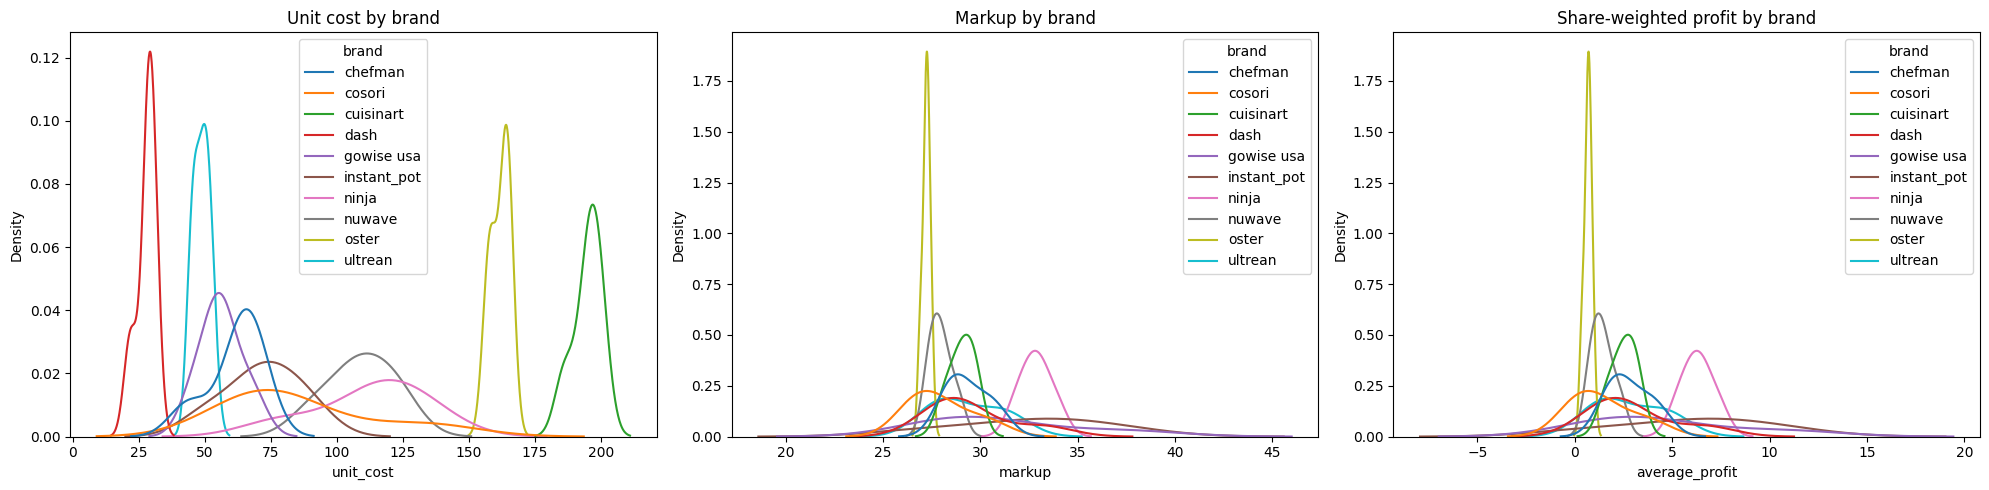

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.kdeplot(data=results, x='unit_cost',      hue='brand', ax=axes[0], common_norm=False)
axes[0].set_title('Unit cost by brand')

sns.kdeplot(data=results, x='markup',         hue='brand', ax=axes[1], common_norm=False)
axes[1].set_title('Markup by brand')

sns.kdeplot(data=results, x='average_profit', hue='brand', ax=axes[2], common_norm=False)
axes[2].set_title('Share-weighted profit by brand')

plt.tight_layout()
plt.show()


**What the densities show.** The unit-cost distribution is bimodal: a fat lump in the \$30-\$80 range (the mass-market brands) and a thinner tail above \$150 driven by Cuisinart and Oster. Markups are tightly concentrated between roughly \$27 and \$37 — the model imposes that the markup depends only on $s_{bt}$ and the constant $\hat{\beta}_{price}$, so brands with similar shares get similar markups. Share-weighted profit is right-skewed: most brand-years sit below \$4, but a few (Ninja, Instant Pot, GoWise USA in 2019) push out beyond \$6.

# 5. Brands with the highest share-weighted average profit

In [11]:
results.loc[:, ['brand', 'average_profit']].groupby('brand').mean().round(3).sort_values('average_profit', ascending=False)


,average_profit
brand,
ninja,6.306
instant_pot,6.010
gowise usa,4.606
dash,2.994
chefman,2.821
ultrean,2.781
cuisinart,2.503
cosori,1.437
nuwave,1.423


**Answer.** The top-ranked brands by share-weighted profit are:

1. **Ninja** ($\approx 6.31$)
2. **Instant Pot** ($\approx 6.01$)
3. **GoWise USA** ($\approx 4.61$)
4. **Dash** ($\approx 2.99$)
5. **Chefman** ($\approx 2.82$)

At the bottom: Oster ($\approx 0.68$), Nuwave ($\approx 1.42$), and Cosori ($\approx 1.44$).

**Conclusion.** In this model, profit ranking is driven much more by share than by markup, because markups are squeezed into a tight range by the constant price slope. The market leaders — Ninja and Instant Pot — combine large shares with markups at the higher end. Cuisinart and Oster command very high prices and very high implied unit costs, but their small shares mean they capture relatively little share-weighted profit despite a per-unit premium. From a strategy standpoint, that suggests the most attractive position in this market is the high-rating, mid-price segment Ninja occupies, not the ultra-premium tier where Cuisinart and Oster compete.